# Non-Thermal Emissions: Gamma-Rays and Multi-Messenger Signatures

In this tutorial, we will explore how to compute observable **non-thermal radiative emissions** (gamma-rays and neutrinos) from cosmic ray distributions in SAETASS.

When high-energy cosmic rays (protons and electrons) propagate through astrophysical environments (such as interstellar clouds, supernova remnants, or stellar wind bubbles) they interact with the surrounding gas, radiation fields, and magnetic fields. These interactions generate secondary observable emissions:

1. **Hadronic mechanisms** (Protons / Hadrons):
   - **Neutral Pion Decay**: Inelastic proton-proton collisions produce neutral pions that rapidly decay into gamma-ray photons ($p + p \to \pi^0 + X \to 2\gamma + X$).
   - **Neutrino Emission**: Charged pion production and subsequent leptonic decay chains produce high-energy neutrinos ($p + p \to \pi^\pm + X \to \nu + X$).

2. **Leptonic mechanisms** (Electrons / Positrons):
   - **Relativistic Bremsstrahlung**: Electrons scattering off target gas nuclei and ambient electrons ($e^- + Z \to e^- + Z + \gamma$).
   - **Inverse Compton Scattering (IC)**: Relativistic electrons upscattering ambient low-energy photons (e.g., CMB, infrared, optical starlight) to gamma-ray energies ($e^- + \gamma_{\mathrm{target}} \to e^- + \gamma_{\mathrm{IC}}$).
   - **Synchrotron Radiation**: Relativistic electrons accelerating in ambient magnetic fields ($e^- + B \to e^- + \gamma_{\mathrm{syn}}$).

SAETASS provides the `EmissionCalculator` utility in `saetass.utils.emissions` to compute these emissivities and observable spectral energy distributions (SEDs) in a fully vectorized and modular framework.

## 1. Setting up the environment and plotting styles

First, we import the required libraries and configure the visual styling for our figures.

In [1]:
import astropy.constants as const
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from saetass.state import State
from saetass.utils.emissions import EmissionCalculator
from saetass.utils.energy_losses import Particle

# Matplotlib formatting for clean presentation
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "mathtext.fontset": "cm",
        "figure.autolayout": True,
    }
)

## 2. Defining Physical Grids and Astrophysical Environment

In SAETASS, `EmissionCalculator` cleanly decouples the static background physical environment and spatial/energy grids from the dynamic particle state.

Let us define:
- `E_out_grid`: The outgoing secondary photon / neutrino energy grid (from 100 MeV to 100 TeV).
- `E_cr_grid`: The primary cosmic ray proton kinetic energy grid (from 100 MeV to 1 PeV).
- `p_cr_grid`: The corresponding cosmic ray proton momentum grid.
- `r_grid`: The radial grid for spatial variations (from 0 pc to 20 pc).
- `n_gas`: The ambient gas number density profile (representing a target cloud/bubble of average density $10\text{ cm}^{-3}$).
- `distance`: The distance from the source to the observer (e.g., $d = 2.0\text{ kpc}$).

In [2]:
# Outgoing photon / neutrino energy grid (100 MeV to 100 TeV)
E_out_grid = np.logspace(-1, 5, 80) * u.GeV

# Primary cosmic ray proton kinetic energy grid (100 MeV to 1 PeV)
E_cr_grid = np.logspace(-1, 6, 150) * u.GeV
# Compute also momentum
p_cr_grid = np.sqrt(E_cr_grid**2 + 2 * E_cr_grid * const.m_p * const.c**2) / const.c

# Spatial radial grid (0 to 20 pc)
r_grid = np.linspace(0, 20, 40) * u.pc

# Ambient gas density profile (uniform 10 cm^-3)
n_gas = 10.0 * np.ones(len(r_grid)) * u.cm**-3

# Distance to the astrophysical source
distance = 2.0 * u.kpc

print(f"Outgoing energy grid: [{E_out_grid[0]:.2f}, {E_out_grid[-1]:.2e}]")
print(f"Primary CR energy grid: [{E_cr_grid[0]:.2f}, {E_cr_grid[-1]:.2e}]")
print(f"Spatial grid: {len(r_grid)} bins from {r_grid[0]} to {r_grid[-1]}")
print(f"Observer distance: {distance}")

Outgoing energy grid: [0.10 GeV, 1.00e+05 GeV]
Primary CR energy grid: [0.10 GeV, 1.00e+06 GeV]
Spatial grid: 40 bins from 0.0 pc to 20.0 pc
Observer distance: 2.0 kpc


## 3. Constructing the Cosmic Ray Proton Population (`State`)

In a realistic astrophysical scenario, cosmic rays accelerated by shock mechanisms (such as supernova remnants or massive stellar clusters) typically follow a power-law distribution with an exponential cutoff:

$$f(r,p) \propto p^{-s} \exp\left(-\frac{p}{p_{\mathrm{cut}}}\right) $$

where:
- $s$ is the spectral power-law index.
- $p_{\mathrm{cut}}$ is the maximum acceleration momentum cutoff.

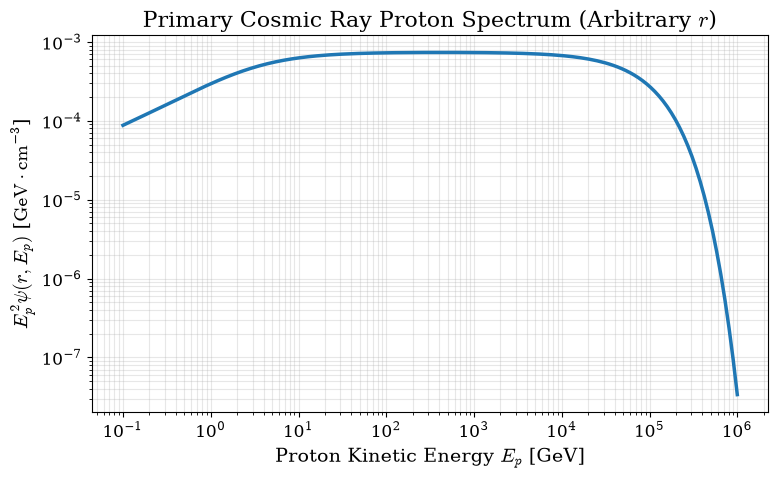

In [3]:
# 1. Define physical phase-state distribution function
s = 4
p_cut = 100.0 * u.TeV / const.c
p_0 = 1.0 * u.GeV / const.c
norm_0 = 1e-4 * (u.cm**-3 * (u.GeV / const.c) ** -3)

# Momentum dependence
spectral_shape = (p_cr_grid / p_0).to_value(u.dimensionless_unscaled) ** (-s) * np.exp(
    -(p_cr_grid / p_cut).to_value(u.dimensionless_unscaled)
)
f_p = norm_0 * spectral_shape

# Spatial dependence
R_0 = 5.0 * u.pc
spatial_profile = np.exp(-0.5 * (r_grid / R_0).to_value(u.dimensionless_unscaled) ** 2)

# 2. Convert f_ps to SAETASS differential distribution psi(p)
f_ps = f_p[:, np.newaxis] * spatial_profile[np.newaxis, :]
f = 4 * np.pi * p_cr_grid[:, np.newaxis] ** 2 * f_ps

# 3. Create the SAETASS Stsate
state_p = State(f=f)

# Visualize the parent proton spectrum
fig, ax = plt.subplots(figsize=(8, 5))
E_GeV = E_cr_grid.to_value(u.GeV)
dp_dE = (const.m_p * const.c**2 + E_cr_grid) / (p_cr_grid * const.c**2)
ax.loglog(E_GeV, (E_cr_grid**2 * f[:, 10] * dp_dE).to_value(u.GeV * u.cm**-3), lw=2.5)
ax.set_xlabel(r"Proton Kinetic Energy $E_p$ [GeV]")
ax.set_ylabel(r"$E_p^2 \psi(r, E_p)$ [$\mathrm{GeV \cdot cm^{-3}}$]")
ax.set_title(r"Primary Cosmic Ray Proton Spectrum (Arbitrary $r$)")
ax.grid(True, which="both", alpha=0.3)
plt.show()

## 4. Computing Hadronic Gamma-Ray Emission ($p + p \to \pi^0 + X \to 2\gamma$)

Now we initialize the `EmissionCalculator` with our grids and physical parameters, specifying `particle=Particle.PROTON`.

We then compute the observable gamma-ray flux using the state-of-the-art **AAFRAG** parametrization (`model="aafragpy"`):

In [4]:
# Initialize EmissionCalculator for protons
calc_p = EmissionCalculator(
    E_out_grid=E_out_grid,
    E_cr_grid=E_cr_grid,
    r_grid=r_grid,
    n_gas=n_gas,
    particle=Particle.PROTON,
    distance=distance,
)

# Compute hadronic pion-decay gamma-ray flux
flux_pion_aafrag = calc_p.compute_pion_decay_emission(state_p, model="aafragpy")

print("Computed gamma-ray flux shape:", flux_pion_aafrag.shape)
print("Flux units:", flux_pion_aafrag.unit)

Computed gamma-ray flux shape: (80,)
Flux units: 1 / (GeV s cm2)


/Users/jmorillo/SAETASS/src/saetass/utils/emissions.py:197: UserWarning: AAFRAG parametrization is only valid for primary proton kinetic energies >= 4 GeV. Cross-sections for lower energies have been set to 0.
  sigma_matrix = cs_model.compute_matrix(


### Visualizing the Gamma-Ray Spectral Energy Distribution (SED)

In high-energy astrophysics, observational spectra are commonly displayed as the **Spectral Energy Distribution** (SED), defined as:

$$\mathrm{SED} = E_\gamma^2 \Phi_\gamma(E_\gamma) = E_\gamma^2 \frac{dN_\gamma}{dA \, dt \, dE_\gamma}$$

in units of $\mathrm{erg \cdot cm^{-2} \cdot s^{-1}}$ or $\mathrm{eV \cdot cm^{-2} \cdot s^{-1}}$.

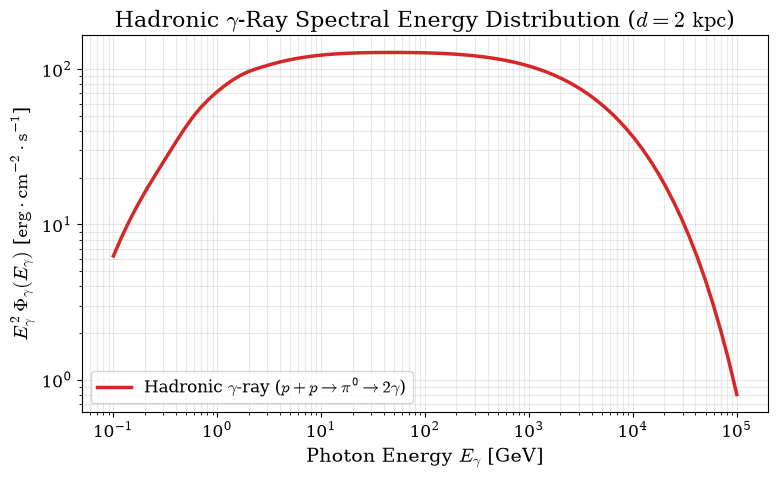

In [5]:
# Compute SED in erg cm^-2 s^-1
SED_gamma = (flux_pion_aafrag * E_out_grid**2).to(u.erg * u.cm**-2 * u.s**-1)

fig, ax = plt.subplots(figsize=(8, 5))
E_gamma_GeV = E_out_grid.to_value(u.GeV)

ax.loglog(
    E_gamma_GeV,
    SED_gamma.value,
    color="#d62728",
    lw=2.5,
    label=r"Hadronic $\gamma$-ray ($p+p \to \pi^0 \to 2\gamma$)",
)
ax.set_xlabel(r"Photon Energy $E_\gamma$ [GeV]")
ax.set_ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma(E_\gamma)$ [$\mathrm{erg \cdot cm^{-2} \cdot s^{-1}}$]"
)
ax.set_title(
    r"Hadronic $\gamma$-Ray Spectral Energy Distribution ($d = 2\ \mathrm{kpc}$)"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left")
plt.show()

Notice two distinctive physical features of the spectrum:
1. **Power-law index inheritance**: In the multi-GeV to TeV regime, the gamma-ray photon index directly mirrors that of the parent proton spectrum.
2. **Cutoff scaling**: The exponential cutoff at $E_\gamma \approx 10\text{ TeV}$ reflects the proton cutoff at $100\text{ TeV}$ reduced by the proton-to-pion inelasticity factor ($E_\gamma \sim 0.1 E_p$).

## 5. Comparison of Hadronic Interaction Models: AAFRAG vs. Kafexhiu

SAETASS supports multiple hadronic interaction parametrizations via `saetass.utils.cross_sections`.

Here we compare two leading models:
- **AAFRAG** (`model="aafragpy"`): Modern parameterization based on LHC collider data and high-energy Monte Carlo generators. Valid for $T_p \ge 4\text{ GeV}$.
- **Kafexhiu** (`model="kafexhiu"`): Analytical parameterization accurate from the kinematic production threshold ($T_p \ge 0.28\text{ GeV}$) up to PeV energies.

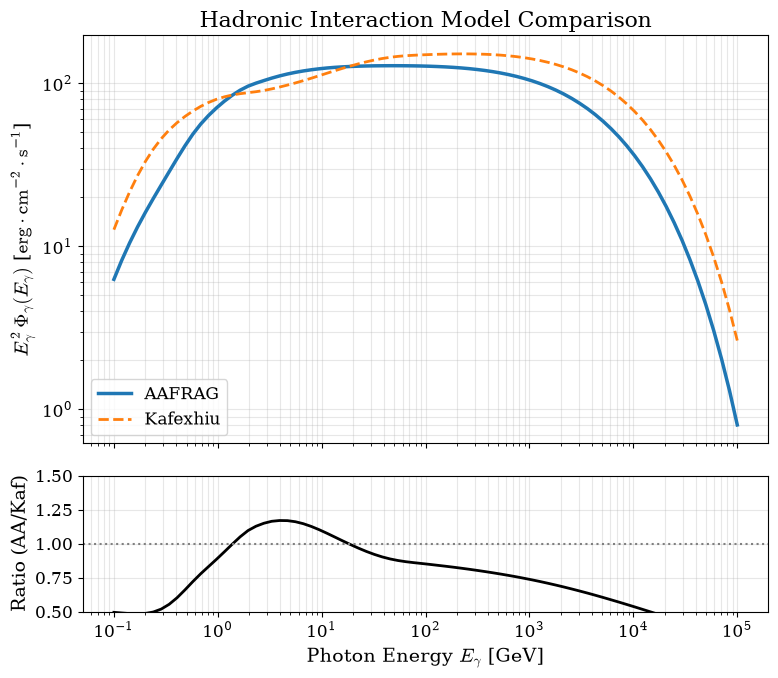

In [6]:
# Compute gamma-ray emission using the Kafexhiu et al. (2014) model
flux_pion_kafexhiu = calc_p.compute_pion_decay_emission(state_p, model="kafexhiu")

SED_aafrag = (flux_pion_aafrag * E_out_grid**2).to(u.erg * u.cm**-2 * u.s**-1)
SED_kafexhiu = (flux_pion_kafexhiu * E_out_grid**2).to(u.erg * u.cm**-2 * u.s**-1)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# Top panel: SED comparison
ax1.loglog(E_gamma_GeV, SED_aafrag.value, lw=2.5, label="AAFRAG")
ax1.loglog(E_gamma_GeV, SED_kafexhiu.value, lw=2, ls="--", label="Kafexhiu")
ax1.set_ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma(E_\gamma)$ [$\mathrm{erg \cdot cm^{-2} \cdot s^{-1}}$]"
)
ax1.set_title("Hadronic Interaction Model Comparison")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(loc="lower left")

# Bottom panel: Ratio
ratio = flux_pion_aafrag.value / np.where(
    flux_pion_kafexhiu.value > 0, flux_pion_kafexhiu.value, np.nan
)
ax2.semilogx(E_gamma_GeV, ratio, color="black", lw=2)
ax2.axhline(1.0, color="gray", ls=":", lw=1.5)
ax2.set_xlabel(r"Photon Energy $E_\gamma$ [GeV]")
ax2.set_ylabel("Ratio (AA/Kaf)")
ax2.set_ylim(0.5, 1.5)
ax2.grid(True, which="both", alpha=0.3)

plt.show()

## 6. Multi-Messenger Connection: Secondary Neutrino Emissions

Inelastic $pp$ collisions also produce charged pions ($\pi^\pm$) with comparable cross-sections. Their subsequent leptonic decays produce an all-flavor neutrino flux:

$$\begin{aligned}
\pi^+ &\to \mu^+ + \nu_\mu \to e^+ + \nu_e + \bar{\nu}_\mu + \nu_\mu \\
\pi^- &\to \mu^- + \bar{\nu}_\mu \to e^- + \bar{\nu}_e + \nu_\mu + \bar{\nu}_\mu
\end{aligned}$$

Because neutrinos interact only via the weak force, they travel unattenuated across the Universe and provide an unambiguous signature of hadronic cosmic ray acceleration.

`EmissionCalculator` computes this all-flavor neutrino flux with a single call:

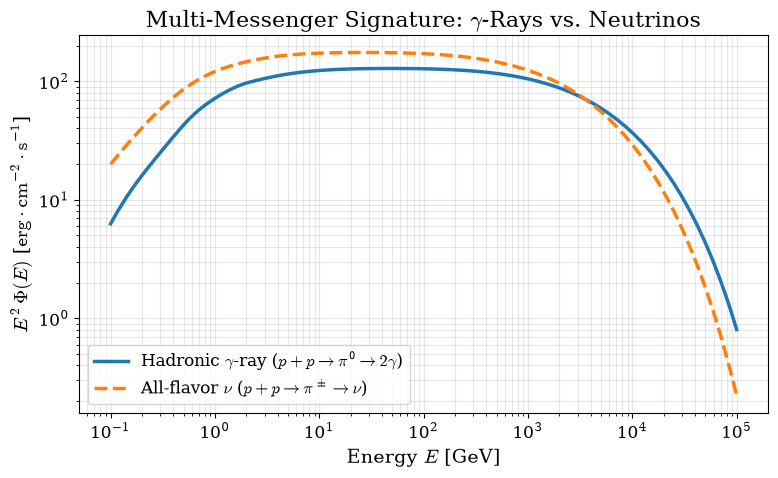

In [7]:
# Compute all-flavor neutrino emission
flux_neutrino = calc_p.compute_neutrino_emission(state_p, model="aafragpy")

SED_neutrino = (flux_neutrino * E_out_grid**2).to(u.erg * u.cm**-2 * u.s**-1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(
    E_gamma_GeV,
    SED_gamma.value,
    lw=2.5,
    label=r"Hadronic $\gamma$-ray ($p+p \to \pi^0 \to 2\gamma$)",
)
ax.loglog(
    E_gamma_GeV,
    SED_neutrino.value,
    lw=2.5,
    ls="--",
    label=r"All-flavor $\nu$ ($p+p \to \pi^\pm \to \nu$)",
)

ax.set_xlabel(r"Energy $E$ [GeV]")
ax.set_ylabel(r"$E^2 \, \Phi(E)$ [$\mathrm{erg \cdot cm^{-2} \cdot s^{-1}}$]")
ax.set_title(r"Multi-Messenger Signature: $\gamma$-Rays vs. Neutrinos")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left")
plt.show()

## 7. Analogy with Leptonic Emissions and Summary

The exact same workflow and API apply to **leptonic emissions** (relativistic electrons / positrons).

For electrons:
1. Initialize the calculator with `particle=Particle.ELECTRON`:
   ```python
   calc_e = EmissionCalculator(
       E_out_grid=E_out_grid,
       E_cr_grid=E_e_grid,
       r_grid=r_grid,
       n_gas=n_gas,
       particle=Particle.ELECTRON,
       distance=distance,
   )
   ```

2. Compute individual leptonic radiative mechanisms:
   - **Bremsstrahlung**:
     ```python
     flux_brems = calc_e.compute_bremsstrahlung_emission(state_e)
     ```
   - **Inverse Compton Scattering** (specifying ambient photon target fields like the CMB):
     ```python
     flux_ic = calc_e.compute_inverse_compton_emission(state_e, eps_grid=eps_grid, dn_deps=dn_deps)
     ```
   - **Synchrotron Radiation** (specifying ambient magnetic field $B$):
     ```python
     flux_sync = calc_e.compute_synchrotron_emission(state_e, B_field=B_field)
     ```

3. Sum all computed leptonic mechanisms into a total gamma-ray SED:
   ```python
   flux_total_gamma = calc_e.compute_total_gamma_emission()
   ```

### Key Takeaways

- `EmissionCalculator` decouples background astrophysics from transport simulation states.
- Fully vectorized 2D integrations deliver high-performance calculations over arbitrary energy grids and spatial domains.
- Seamlessly integrates with the outputs of SAETASS transport solvers (`Solver.advance()`) to generate synthetic observable spectra and multi-messenger predictions.